### ___Multi Response Phylogenetic Mixed Models `MR-PMM` using Markov Chain Monte Carlo generalized linear mixed models `MCMCglmm`___
----------------------

In [1]:
print(R.version$version.string)

[1] "R version 4.6.0 (2026-04-24 ucrt)"


In [2]:
# https://benjamin-halliwell.github.io/MR-PMM/MR-PMM_tutorial.html
# https://benjamin-halliwell.github.io/MR-PMM/MR-PMM_euc_example_analysis.html
# https://paulbuerkner.com/brms/articles/index.html
# https://paulbuerkner.com/brms/articles/brms_phylogenetics.html
# https://journal.r-project.org/articles/RJ-2018-017/index.html

In [4]:
suppressPackageStartupMessages({
    library("ape")
    library("phytools") 
    library("nlme")
    library("U.PhyloMaker")
    library("phylolm")
    library("geiger")
    library("brms") # https://github.com/paul-buerkner/brms
})

### ___1. Phylogeny___
---------------------------

In [ ]:
megatree <- ape::read.tree("../../data/chapter2/uphylomaker/GBOTB.extended.TPL.tre") # TPL megatree
# the order info in the FRED 4.0 subset dataset wasn't cross checked!!!!
traits <- read.csv("../../data/chapter2/FRED/subsets/final") # FRED 4.0 subset with names reconciled with the megatree by hand
# this does not need programmatic name reconciliations
traits$binominal <- gsub(traits$binominal, pattern = ' ', replacement = '_')
synonyms <- read.csv("../../data/chapter2/wcvp/synonyms.csv") # WCVP synonyms

In [7]:
#---------------------------
# phylogeney construction
#---------------------------

# species, genus, family, species.relative, genus.relative
species_list <- data.frame(species = traits$binominal, genus = traits$F01286, family = NA, species.relative = NA, genus.relative = NA)
genus_list <- data.frame(genus = traits$F01286, family = traits$F01289) 
phy <- U.PhyloMaker::phylo.maker(sp.list = species_list, gen.list = genus_list, tree = megatree)

In [8]:
ape::write.tree(phy = phy$phylo, file = "../../data/chapter2/uphylomaker/FRED4_1301_species.tre")

In [22]:
stopifnot(all(traits[match(phy$phylo$tip.label, traits$binominal), ]$binominal == phy$phylo$tip.label))
traits <- traits[match(phy$phylo$tip.label, traits$binominal), ]
write.csv(traits, "../../data/chapter2/FRED/subsets/final_name_matched.csv", row.names = FALSE)

### ___2. Phylogenetic signal and pairwise relationships___
---------------------------

In [6]:
GEIGER_FITCONTINUOUS_MODEL_OPTIONS <- c("BM", "OU", "EB", "rate_trend", "lambda", "kappa", "delta", "mean_trend", "white")
PHYLOLM_PHYLOLM_MODEL_OPTIONS <- c("BM", "OUrandomRoot", "OUfixedRoot", "lambda", "kappa", "delta", "EB", # "trend", - "trend" option is problematic for ultrametric trees
                                   "GC")

In [8]:
# this phylogeny needs to be fully bifurcating with no polytomies
tree <- ape::read.tree("../../data/chapter2/uphylomaker/FRED4_1301.tre") # the phylogeny of the 1301 FRED 4.0 subset species

In [10]:
if(!ape::is.binary(tree)) tree <- ape::multi2di(tree, random = FALSE) # split polytomies into binary 0 length branches

# make the phylogeny completely bifurcating by replacing 0 length branches
tree$edge.length[tree$edge.length <= 0] <- rnorm(n = sum(tree$edge.length == 0), mean = 1e-6, sd = 1e-8) # replace the 0 length edges with random noise
stopifnot(!sum(tree$edge.length <= 0)) # no more 0 length branches

# this must be done after altering the branch lengths
if (!ape::is.ultrametric(tree)) tree <- phytools::force.ultrametric(tree = tree, method = "extend") # this needs to be done after replacing the 0 length branches with small non zero noise

stopifnot(ape::is.binary(tree) && ape::is.ultrametric(tree))

traits <- read.csv("../../data/chapter2/FRED/subsets/name_matched_FRED4_1301.csv", row.names = "binominal") # we need the binominal names as row names for phylolm::phylolm()

# repeat the taxonomic corrections
# traits[traits$F01286 %in% c("Parablechnum", "Lomaria", "Blechnopsis"), "F01286"] = "Blechnum"
# traits[traits$F01286 == "Pseudodiphasium", "F01286"] = "Lycopodium"
# traits[traits$F01286 %in% c("Richetia", "Rubroshorea"), "F01286"] = "Shorea"

# traits["binominal"] <- paste0(traits$F01286, '_', traits$F01287)
# stopifnot(length(traits$binominal)==length(tree$tip.label))
# stopifnot(sum(tree$tip.label %in% traits$binominal) == length(tree$tip.label))
# traits <- traits[match(tree$tip.label, traits$binominal), ] # name matching the dataset and the phylogeny

stopifnot(all(tree$tip.label==traits$binominal)) # the current traits dataset has already been name matched with the phylogeny!!!!!!!!

In [11]:
head(traits)

,F01286,F01289,F00679,F00679_se,F00727,F00727_se,F00709,F00709_se,state,state_source,synonym
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
Ratibida_pinnata,Ratibida,Asteraceae,-0.8209806,NA,4.025352,NA,-2.120264,NA,AM,"(Soudzilovskaia et al., 2020)","('Lepachys pinnata', 'Rudbeckia pinnata', 'Helianthus pinnatus', 'Obeliscaria pinnata')"
Heliopsis_helianthoides,Heliopsis,Asteraceae,-0.9675840,NA,4.158883,NA,-1.966113,NA,AM,"(Brundrett and Tedersoo, 2018)","('Buphthalmum helianthoides',)"
Liatris_aspera,Liatris,Asteraceae,-0.7985077,NA,4.382027,NA,-2.525729,NA,AM,(Maherali et. al. 2016),"('Lacinaria scariosa var. aspera', 'Lacinaria aspera')"
Arnica_sororia,Arnica,Asteraceae,-1.4134600,NA,4.342257,NA,-1.203973,NA,AM,"(Soudzilovskaia et al., 2020)","('Arnica fulgens var. sororia',)"
Arnica_fulgens,Arnica,Asteraceae,-0.6627150,NA,2.765172,NA,-1.124452,NA,AM,(Maherali et. al. 2016),"('Arnica montana var. fulgens',)"
Hymenoxys_richardsonii,Hymenoxys,Asteraceae,-1.2644308,NA,4.235371,NA,-1.460061,NA,AM,"(Soudzilovskaia et al., 2020)","('Picradenia richardsonii', 'Actinea richardsonii', 'Actinella richardsonii')"


In [63]:
# the tutorial uses the R library phylolm
# nlme::gls requires a correlation matrix - ape provides only limited options (Brownian, Bloomberg, Pagel et.c.) for this

suppressWarnings(
    rbind(
        SRL.RD = mapply(PHYLOLM_PHYLOLM_MODEL_OPTIONS, FUN = function (m) phylolm::phylolm(F00727 ~ F00679, data = traits, model = m, phy = tree)$aic), # SRL ~ RD
        RD.SRL = mapply(PHYLOLM_PHYLOLM_MODEL_OPTIONS, FUN = function (m) phylolm::phylolm(F00679 ~ F00727, data = traits, model = m, phy = tree)$aic) # RD ~ SRL
    )
)

,BM,OUrandomRoot,OUfixedRoot,lambda,kappa,delta,EB,GC
SRL.RD,4340.725,2917.8101,2917.8101,2342.3040,2532.9360,4237.162,4342.725,3036.2211
RD.SRL,2002.748,661.4962,661.4962,169.3322,405.0684,1901.315,2004.748,938.3773


In [64]:
suppressWarnings(
    rbind(
        SRL.RTD = mapply(PHYLOLM_PHYLOLM_MODEL_OPTIONS, FUN = function (m) phylolm::phylolm(F00727 ~ F00709, data = traits, model = m, phy = tree)$aic), # SRL ~ RTD
        RTD.SRL = mapply(PHYLOLM_PHYLOLM_MODEL_OPTIONS, FUN = function (m) phylolm::phylolm(F00709 ~ F00727, data = traits, model = m, phy = tree)$aic) # RTD ~ SRL
    )
)

,BM,OUrandomRoot,OUfixedRoot,lambda,kappa,delta,EB,GC
SRL.RTD,4598.274,3506.664,3506.664,3016.570,3177.735,4499.339,4600.274,3645.258
RTD.SRL,3157.692,1992.819,1992.819,1544.616,1733.519,3058.137,3159.692,2177.964


In [65]:
suppressWarnings(
    rbind(
        RTD.RD = mapply(PHYLOLM_PHYLOLM_MODEL_OPTIONS, FUN = function (m) phylolm::phylolm(F00709 ~ F00679, data = traits, model = m, phy = tree)$aic), # RTD ~ RD
        RD.RTD = mapply(PHYLOLM_PHYLOLM_MODEL_OPTIONS, FUN = function (m) phylolm::phylolm(F00679 ~ F00709, data = traits, model = m, phy = tree)$aic) # RD ~ RTD
    )
)

,BM,OUrandomRoot,OUfixedRoot,lambda,kappa,delta,EB,GC
RTD.RD,3754.571,2467.833,2467.833,1940.750,2097.047,3652.552,3756.571,2547.834
RD.RTD,2857.176,1725.364,1725.364,1239.566,1413.929,2757.907,2859.176,1917.285


In [12]:
table(traits$state)


   AM   EcM EcMAM   ErM    NM  NMAM 
 1097   121    20     9    16    38 

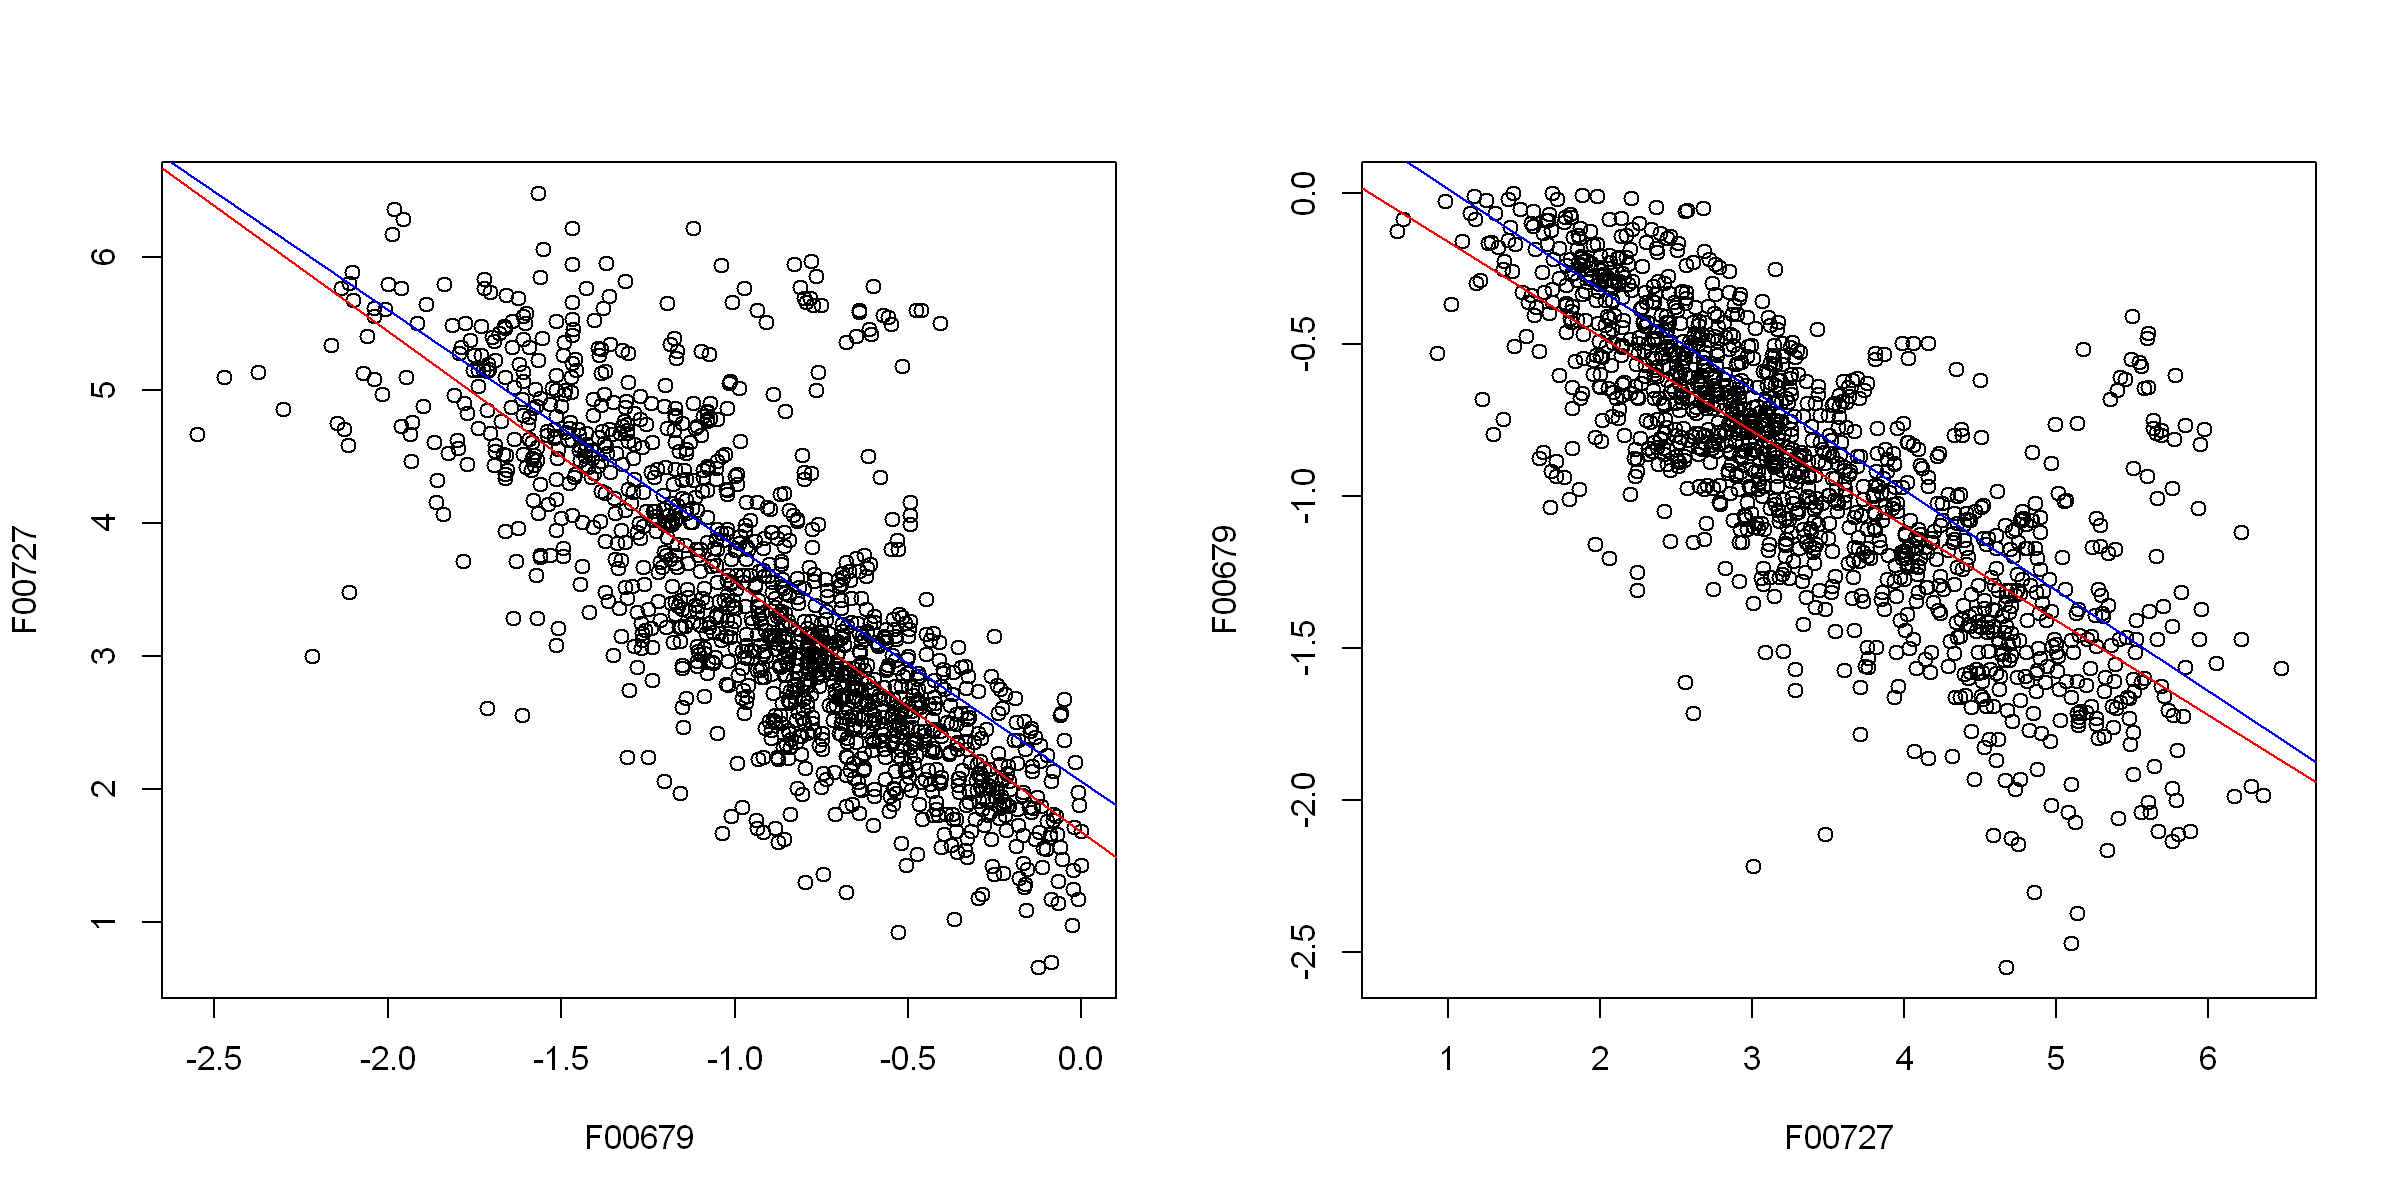

In [13]:
#------------
# SRL & RD
#------------

options(repr.plot.width = 12, repr.plot.height = 6, repr.plot.res = 200)
par(mfrow = c(1, 2))

plot(F00727 ~ F00679, data = traits)
abline(lm(F00727 ~ F00679, data = traits), col = "red")
abline(phylolm::phylolm(F00727 ~ F00679, data = traits, model = "lambda", phy = tree), col = "blue")

plot(F00679 ~ F00727, data = traits)
abline(lm(F00679 ~ F00727, data = traits), col = "red")
abline(phylolm::phylolm(F00679 ~ F00727, data = traits, model = "lambda", phy = tree), col = "blue")

# summary(modp)

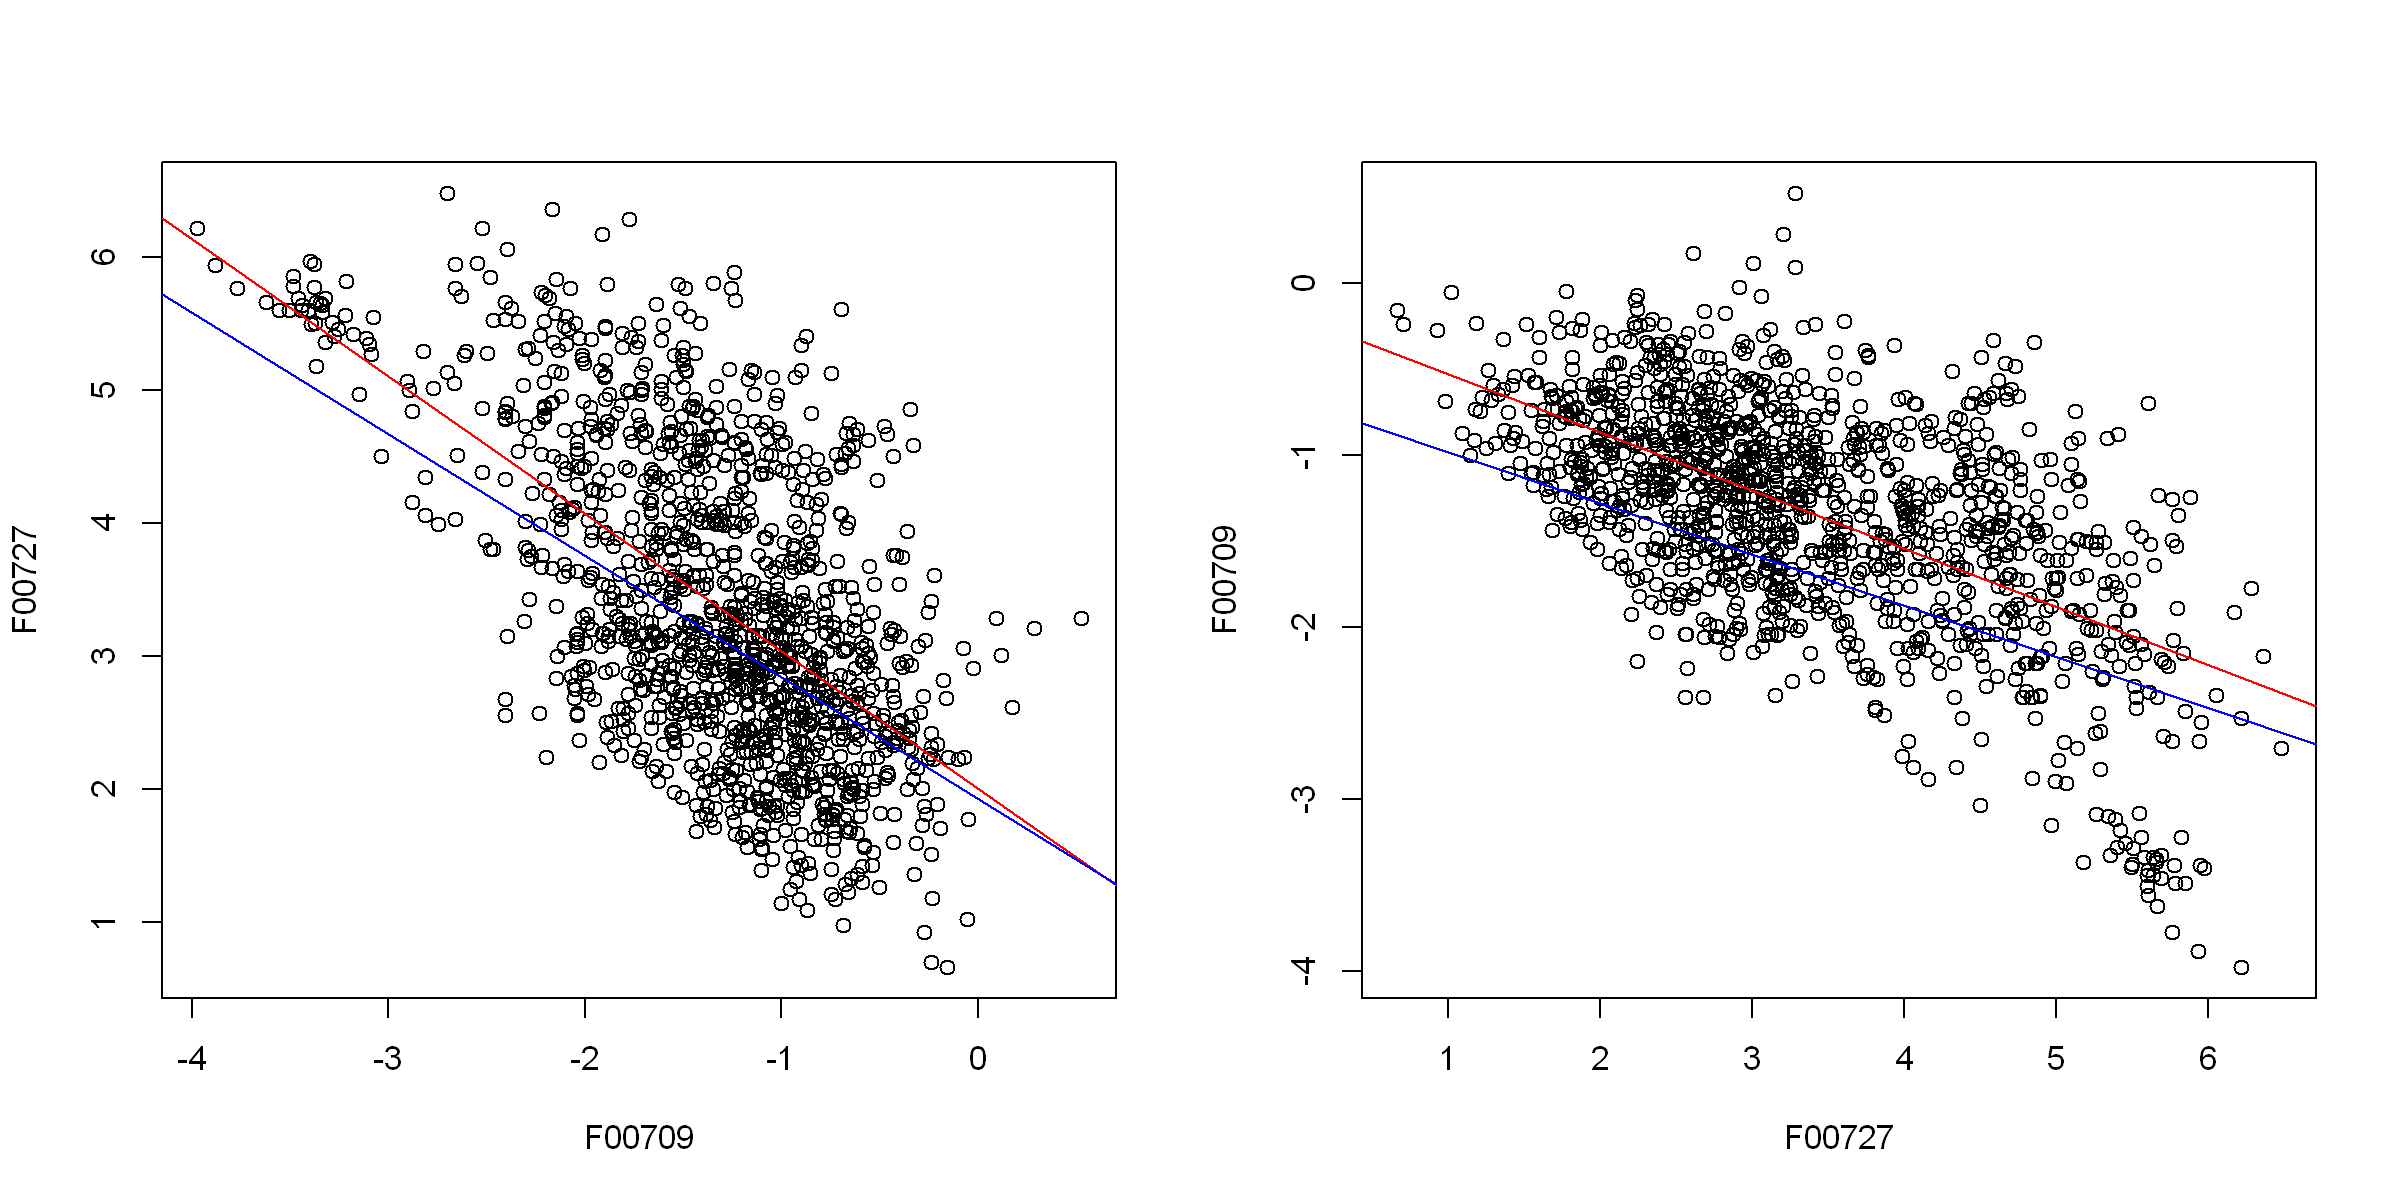

In [14]:
#------------
# SRL & RTD
#------------

par(mfrow = c(1, 2))
plot(F00727 ~ F00709, data = traits)
abline(lm(F00727 ~ F00709, data = traits), col = "red")
abline(phylolm::phylolm(F00727 ~ F00709, data = traits, model = "lambda", phy = tree), col = "blue")

plot(F00709 ~ F00727, data = traits)
abline(lm(F00709 ~ F00727, data = traits), col = "red")
abline(phylolm::phylolm(F00709 ~ F00727, data = traits, model = "lambda", phy = tree), col = "blue")

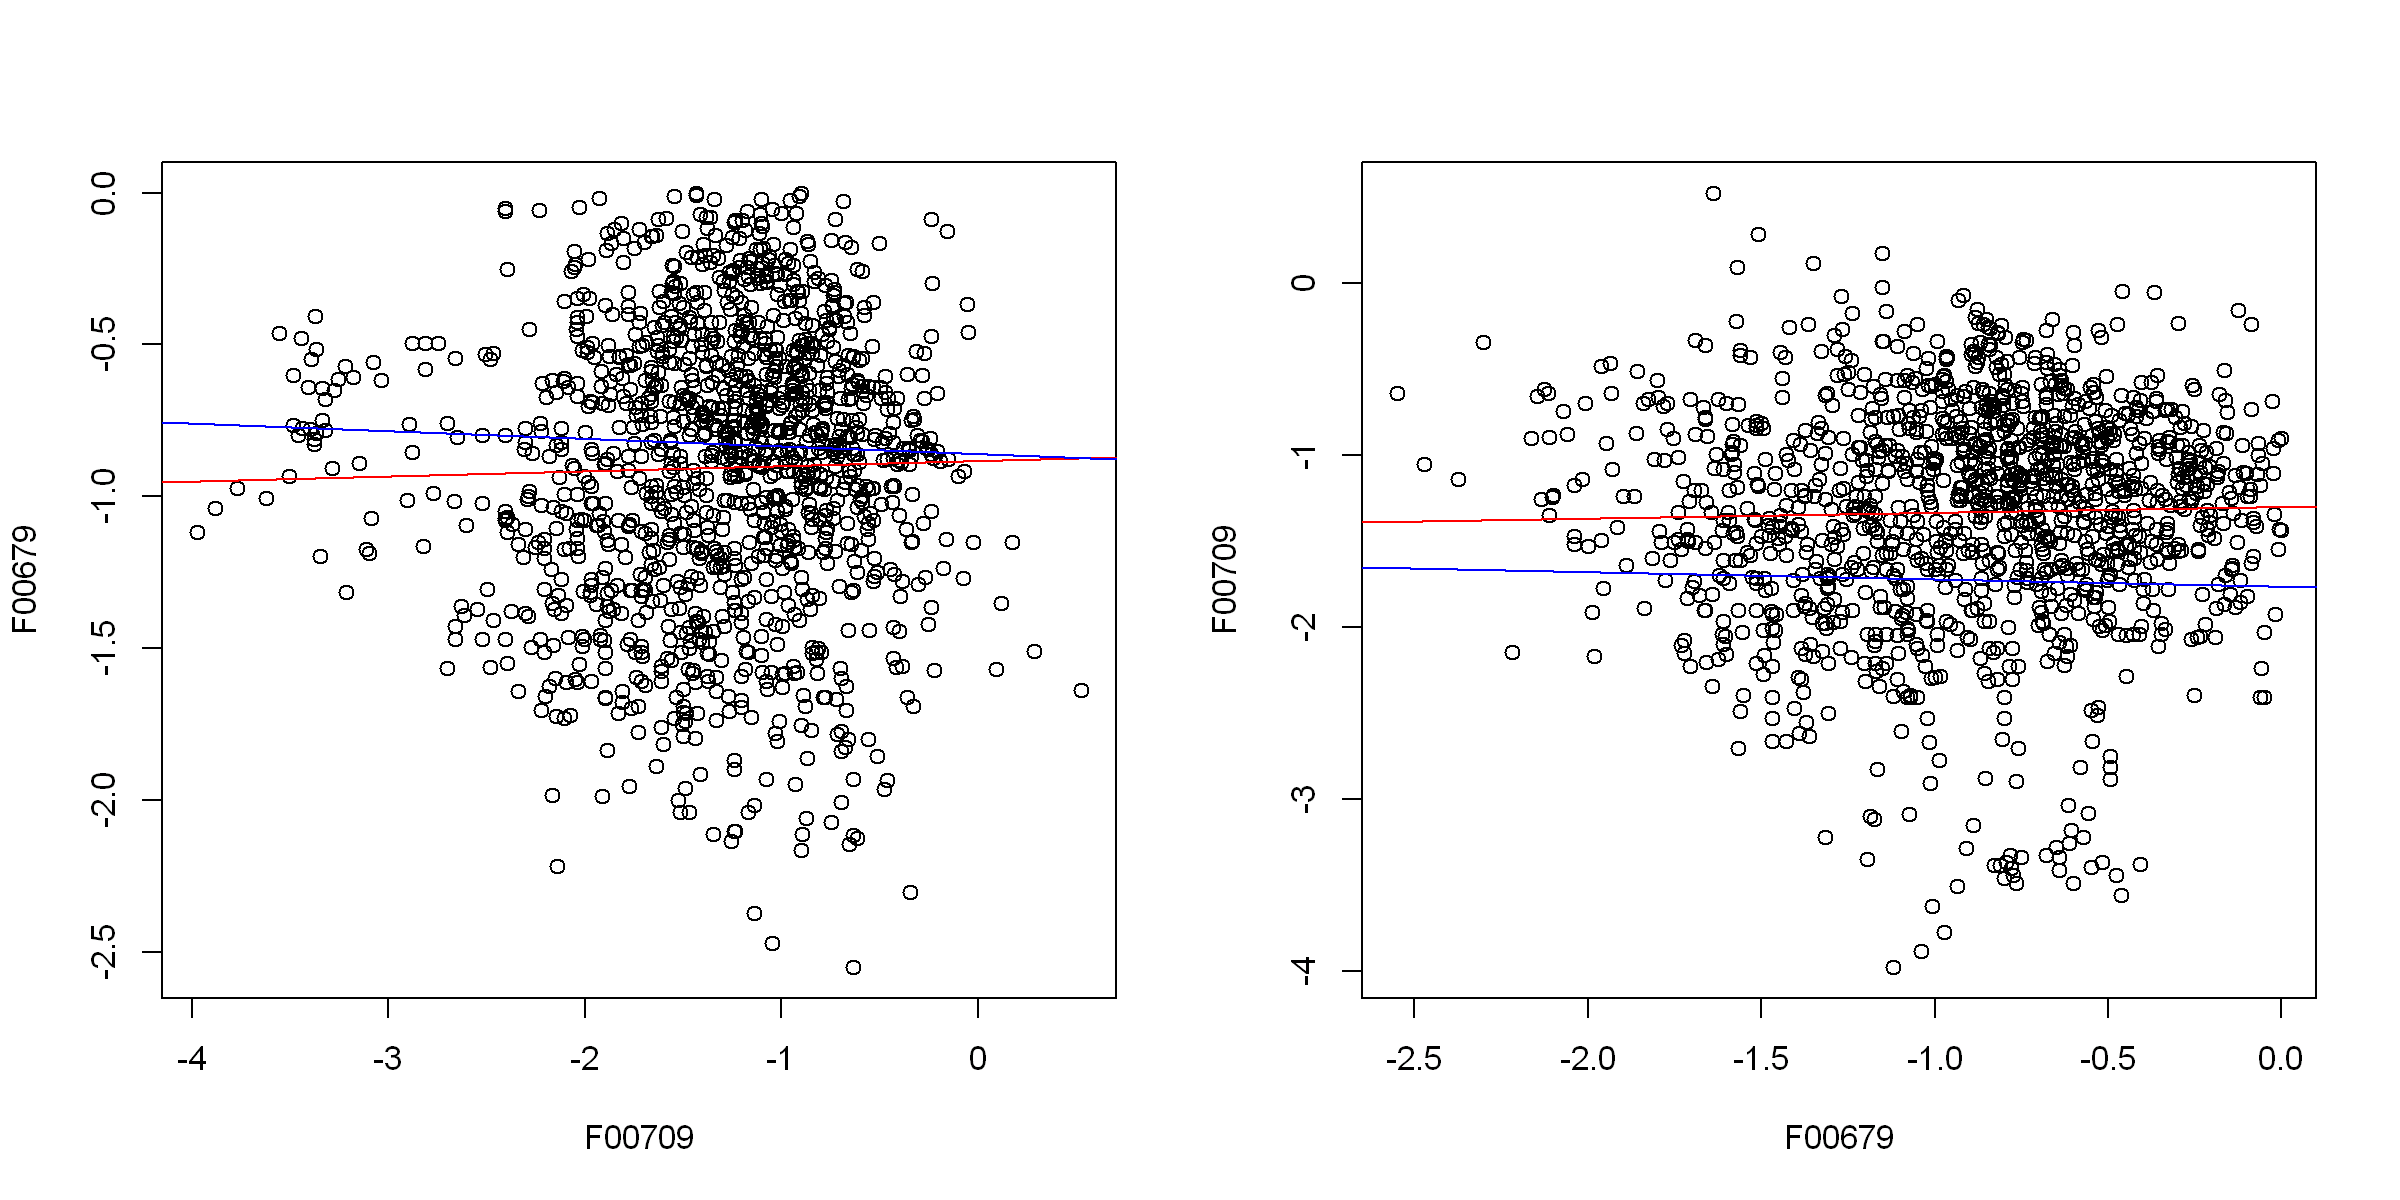

In [15]:
#------------
# RD & RTD
#------------

par(mfrow = c(1, 2))
plot(F00679 ~ F00709, data = traits)
abline(lm(F00679 ~ F00709, data = traits), col = "red")
abline(phylolm::phylolm(F00679 ~ F00709, data = traits, model = "lambda", phy = tree), col = "blue")

plot(F00709 ~ F00679, data = traits)
abline(lm(F00709 ~ F00679, data = traits), col = "red")
abline(phylolm::phylolm(F00709 ~ F00679, data = traits, model = "lambda", phy = tree), col = "blue")

In [120]:
# evern after accounting for phylogenetic relatedness, RD ~ SRL and SRL ~ RTD trait pairs show significant relationships
# so, next step, calculate how much phylogenetic signal is present in our continuous traits?? because the above could be a result of our dataset having little to no phylogenetic signal???

In [27]:
# INVESTIGATE THE PHYLOGENETIC SIGNAL IN THE CONTINUOUS TRAITS
# lambda method is best suited for detecting phylogenetic signals lesser (weaker) than that's expected under a BM model - not good for signals stronger than that of a BM model
# lambda < 1 corresponds to less phylogenetic signal than expected under a BM model

# all the continuous traits have already been log transformed
physig_srl <- phytools::phylosig(tree = tree, method = "lambda", x = setNames(traits$F00727, nm = rownames(traits)), test = TRUE)
physig_rd <- phytools::phylosig(tree = tree, method = "lambda", x = setNames(traits$F00679, nm = rownames(traits)), test = TRUE)
physig_rtd <- phytools::phylosig(tree = tree, method = "lambda", x = setNames(traits$F00709, nm = rownames(traits)), test = TRUE)

In [ ]:
# all the three traits have pretty similar lambda values and all of them are closer to 1.0 than to 0.0
# this tells us that we can reject the null hypothesis that lambda = 0 (with reference to the p values)
# LR stands for Likelihood Ratio

In [28]:
physig_srl


Phylogenetic signal lambda : 0.833651 
logL(lambda) : -1702.85 
LR(lambda=0) : 623.519 
P-value (based on LR test) : 1.2835e-137 


In [29]:
physig_rd


Phylogenetic signal lambda : 0.828158 
logL(lambda) : -616.319 
LR(lambda=0) : 466.128 
P-value (based on LR test) : 2.23079e-103 


In [30]:
physig_rtd


Phylogenetic signal lambda : 0.831478 
logL(lambda) : -966.91 
LR(lambda=0) : 630.01 
P-value (based on LR test) : 4.97377e-139 


In [44]:
# now test for the hypothesis that lambda = 1 (the phylogenetic signal observed is no more significant than what could be generated by a stochastic BM process)
# the $lik attribute of a phylosig object is the function used for its optimization

# likelihood of lambda = 1 is physig_srl$lik(1.00)
# then compare it to the MLE of lambda
lr_srl <- -2 * (physig_srl$lik(1.00) - physig_srl$logL) # page 97 - Phylogenetic Comparative Methods in R

# then compute the p statistic for our LR by comparing it to a chi squared dist with 1 degrees of freedom
pchisq(q = lr_srl, df = 1, lower.tail = FALSE) # p = 0, so we can reject the null hypothesis, which in this case is lambda = 1

[1] 0

In [45]:
# for RTD
pchisq(q = -2 * (physig_rtd$lik(1.00) - physig_rtd$logL), df = 1, lower.tail = FALSE)

[1] 0

In [46]:
# for RD
pchisq(q = -2 * (physig_rd$lik(1.00) - physig_rd$logL), df = 1, lower.tail = FALSE)

[1] 0

In [ ]:
# in conclusion; lambda != 1 and lambda != 0 for all the three continuous traits according to Pagel's lambda test

In [70]:
# now do Bloomberg's K test for all the three traits => most papers report both not just one
# Bloomberk's K is a normalized ratio of comparing variance among clades to variance within clades
# for a simple BM model of evolution, Bloomberg's K must be 1.00

physig_srl <- phytools::phylosig(tree = tree, method = "K", x = setNames(traits$F00727, nm = rownames(traits)), test = TRUE, nsim = 10000)
physig_rd <- phytools::phylosig(tree = tree, method = "K", x = setNames(traits$F00679, nm = rownames(traits)), test = TRUE, nsim = 10000)
physig_rtd <- phytools::phylosig(tree = tree, method = "K", x = setNames(traits$F00709, nm = rownames(traits)), test = TRUE, nsim = 10000)

In [71]:
physig_rd


Phylogenetic signal K : 0.0234281 
P-value (based on 10000 randomizations) : 1e-04 


In [72]:
physig_srl


Phylogenetic signal K : 0.0228481 
P-value (based on 10000 randomizations) : 1e-04 


In [73]:
physig_rtd


Phylogenetic signal K : 0.0319059 
P-value (based on 10000 randomizations) : 1e-04 


In [ ]:
# in our case, all the three traits show a K that is less than expected from a BM model of evolution

In [47]:
# for an explanation on non BM models - https://lukejharmon.github.io/pcm/chapter6_beyondbm/
# page 100 of Phylogenetic Comparative Methods in R
# PAY ATTENTION TO THE WARNING MESSAGES HERE!!!!!!!!

tm <- Sys.time()

SRL_model_fits <- list()
RD_model_fits <- list()
RTD_model_fits <- list()

for (m in GEIGER_FITCONTINUOUS_MODEL_OPTIONS) {
    SRL_model_fits[[m]] <- geiger::fitContinuous(phy = tree, dat = traits["F00727"], model = m)
    RD_model_fits[[m]] <- geiger::fitContinuous(phy = tree, dat = traits["F00679"], model = m)
    RTD_model_fits[[m]] <- geiger::fitContinuous(phy = tree, dat = traits["F00709"], model = m)
    print(paste0("all ", m, " fits done!"))
}

tm <- Sys.time() - tm

save(SRL_model_fits, RD_model_fits, RTD_model_fits, file = "../../data/chapter2/rdata/SRL_RD_RTD_geiger_fitContinuous.RData")

[1] "all BM fits done!"
[1] "all OU fits done!"


Warning message in geiger::fitContinuous(phy = tree, dat = traits["F00679"], model = m):
"
Parameter estimates appear at bounds:
	a"


[1] "all EB fits done!"
[1] "all rate_trend fits done!"
[1] "all lambda fits done!"
[1] "all kappa fits done!"
[1] "all delta fits done!"
[1] "all mean_trend fits done!"
[1] "all white fits done!"


In [48]:
tm # not bad at all :)

Time difference of 6.48128 mins

In [50]:
# inspect the EB models 

SRL_model_fits[["EB"]]$opt # alpha is near zero - in this case EB models regress to a constant rate BM model, this does not need to be corrected since this is not an error!
# page 101 - Phylogenetic Comparative Methods in R

$a
[1] -1.000012e-06

$sigsq
[1] 0.1739684

$z0
[1] 3.578437

$lnL
[1] -2595.165

$method
[1] "subplex"

$k
[1] 3

$aic
[1] 5196.33

$aicc
[1] 5196.349

In [97]:
load("../../data/chapter2/rdata/SRL_RD_RTD_geiger_fitContinuous.RData") # reusing the serialized model fits

# for all the three continuous traits lambda seems to be the best model, followed by kappa and then OU??????

# AICc table
cbind(
    SRL = mapply(SRL_model_fits, FUN = function(m) m$opt$aicc),
    RD = mapply(RD_model_fits, FUN = function(m) m$opt$aicc),
    RTD = mapply(RTD_model_fits, FUN = function(m) m$opt$aicc)
)

,SRL,RD,RTD
BM,5194.320,2856.344,3753.738
OU,3929.309,1673.022,2363.545
EB,5196.349,2858.372,3755.767
rate_trend,5142.831,2805.895,3701.958
lambda,3411.727,1238.656,1939.839
kappa,3541.946,1414.510,2097.660
delta,5092.885,2757.039,3651.684
mean_trend,5196.329,2858.353,3755.747
white,4033.236,1702.775,2567.840


In [54]:
# AIC weights table

cbind(
    SRL = aic.w(mapply(SRL_model_fits, FUN = function(m) AIC(m))),
    RD = aic.w(mapply(RD_model_fits, FUN = function(m) AIC(m))),
    RTD = aic.w(mapply(RTD_model_fits, FUN = function(m) AIC(m)))
)

,SRL,RD,RTD
BM,0.000000e+00,0.000000e+00,0.000000e+00
OU,4.059008e-113,4.771765e-95,9.851911e-93
EB,0.000000e+00,0.000000e+00,0.000000e+00
rate_trend,0.000000e+00,0.000000e+00,0.000000e+00
lambda,1.000000e+00,1.000000e+00,1.000000e+00
kappa,5.281734e-29,6.536003e-39,5.388475e-35
delta,0.000000e+00,0.000000e+00,0.000000e+00
mean_trend,0.000000e+00,0.000000e+00,0.000000e+00
white,1.093630e-135,1.644340e-101,4.259908e-137


## ___`MR-PMM` using `brms`___
---------------------

In [40]:
# let's use the raw subset with duplicates
fred4 <- read.csv("../../data/chapter2/FRED/subsets/continuous_raw.csv")
head(fred4)

,binominal,F01286,F01287,F01289,F00679,F00727,F00709
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>
1,Larix_gmelinii,Larix,gmelinii,Pinaceae,0.3194115,32.211568,0.3542858
2,Larix_gmelinii,Larix,gmelinii,Pinaceae,0.4115552,25.480815,0.2942859
3,Larix_gmelinii,Larix,gmelinii,Pinaceae,0.5276214,12.980828,0.3828573
4,Larix_gmelinii,Larix,gmelinii,Pinaceae,0.8469749,6.250067,0.3342859
5,Larix_gmelinii,Larix,gmelinii,Pinaceae,0.3074501,34.615414,0.3828572
6,Larix_gmelinii,Larix,gmelinii,Pinaceae,0.4594009,26.442353,0.2600002


In [41]:
# duplicating the binominal column with another name as brms won't allow the same variable to be duplicated as random effects (phylogenetic and non phylogenetic)
fred4$taxa <- fred4$binominal
head(fred4)

,binominal,F01286,F01287,F01289,F00679,F00727,F00709,taxa
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>
1,Larix_gmelinii,Larix,gmelinii,Pinaceae,0.3194115,32.211568,0.3542858,Larix_gmelinii
2,Larix_gmelinii,Larix,gmelinii,Pinaceae,0.4115552,25.480815,0.2942859,Larix_gmelinii
3,Larix_gmelinii,Larix,gmelinii,Pinaceae,0.5276214,12.980828,0.3828573,Larix_gmelinii
4,Larix_gmelinii,Larix,gmelinii,Pinaceae,0.8469749,6.250067,0.3342859,Larix_gmelinii
5,Larix_gmelinii,Larix,gmelinii,Pinaceae,0.3074501,34.615414,0.3828572,Larix_gmelinii
6,Larix_gmelinii,Larix,gmelinii,Pinaceae,0.4594009,26.442353,0.2600002,Larix_gmelinii


In [42]:
tree <- ape::read.tree("../../data/chapter2/uphylomaker/FRED4_1301.tre")
corrmat <- ape::vcv.phylo(phy = tree, corr = TRUE)

In [43]:
tree$tip.label[!tree$tip.label %in% fred4$binominal]

character(0)

In [ ]:
# an example multilevel model with two variables
# https://paulbuerkner.com/brms/articles/brms_phylogenetics.html

# this is essentially a PGLS model - (1|binominal) would've fitted random intercepts to the species names without accounting for the phylogenetic relationships between those species
# (1|gr(binominal, cov = corrmat)) specifies that the relationships between the `binominal` are to be inferred from the covariance matrix `cov`

model <- brms::brm(
  F00727 ~ F00679 + (1|gr(binominal, cov = corrmat)) + (1|taxa), # (1|gr(binominal, cov = corrmat)) will capture phylogenetic between species trait correlation while (1|taxa) will capture the non-phylogenetic between species trait correlation
  data = fred4, 
  family = gaussian(),
  data2 = list(corrmat = corrmat), # data2 argument is to pass extra data that does not conform to the formulae's format
  prior = c(
    prior(normal(0, 10), "b"),
    prior(normal(0, 50), "Intercept"),
    prior(student_t(3, 0, 20), "sd"),
    prior(student_t(3, 0, 20), "sigma")
  ),
  threads = 20
)

Compiling Stan program...


Please download and install the appropriate version of Rtools for 4.6.0 from
https://cran.r-project.org/bin/windows/Rtools/.

Trying to compile a simple C file



Running "C:/R-4.6.0/bin/x64/Rcmd.exe" SHLIB foo.c
The system cannot find the path specified.
using C compiler: 'gcc.exe (GCC) 14.3.0'
gcc  -I"C:/R-4.6.0/include" -DNDEBUG     -I"C:/rtools45/x86_64-w64-mingw32.static.posix/include"      -O2 -Wall -std=gnu2x  -mfpmath=sse -msse2 -mstackrealign   -c foo.c -o foo.o
gcc -shared -s -static-libgcc -o foo.dll tmp.def foo.o -LC:/rtools45/x86_64-w64-mingw32.static.posix/lib/x64 -LC:/rtools45/x86_64-w64-mingw32.static.posix/lib -LC:/R-4.6.0/bin/x64 -lR



Please download and install the appropriate version of Rtools for 4.6.0 from
https://cran.r-project.org/bin/windows/Rtools/.

Warning message in system2(file.path(Sys.getenv("R_HOME"), "bin", "R"), args = "CMD SHLIB --dry-run", :
"running command '"C:/R-4.6.0/bin/R" CMD SHLIB --dry-run' had status 1"
Start sampling



In [7]:
summary(model)

 Family: gaussian 
  Links: mu = identity 
Formula: phenotype ~ cofactor + (1 | gr(species, cov = vcv_matrix)) 
   Data: data (Number of observations: 200) 
  Draws: 4 chains, each with iter = 2000; warmup = 1000; thin = 1;
         total post-warmup draws = 4000

Multilevel Hyperparameters:
~species (Number of levels: 200) 
              Estimate Est.Error l-95% CI u-95% CI Rhat Bulk_ESS Tail_ESS
sd(Intercept)    14.47      2.23    10.35    19.20 1.00      981     1628

Regression Coefficients:
          Estimate Est.Error l-95% CI u-95% CI Rhat Bulk_ESS Tail_ESS
Intercept    38.18      7.13    23.61    51.94 1.00     2228     2219
cofactor      5.18      0.14     4.91     5.45 1.00     6006     3302

Further Distributional Parameters:
      Estimate Est.Error l-95% CI u-95% CI Rhat Bulk_ESS Tail_ESS
sigma     9.22      0.72     7.86    10.65 1.00     1253     1870

Draws were sampled using sampling(NUTS). For each parameter, Bulk_ESS
and Tail_ESS are effective sample size measures, a

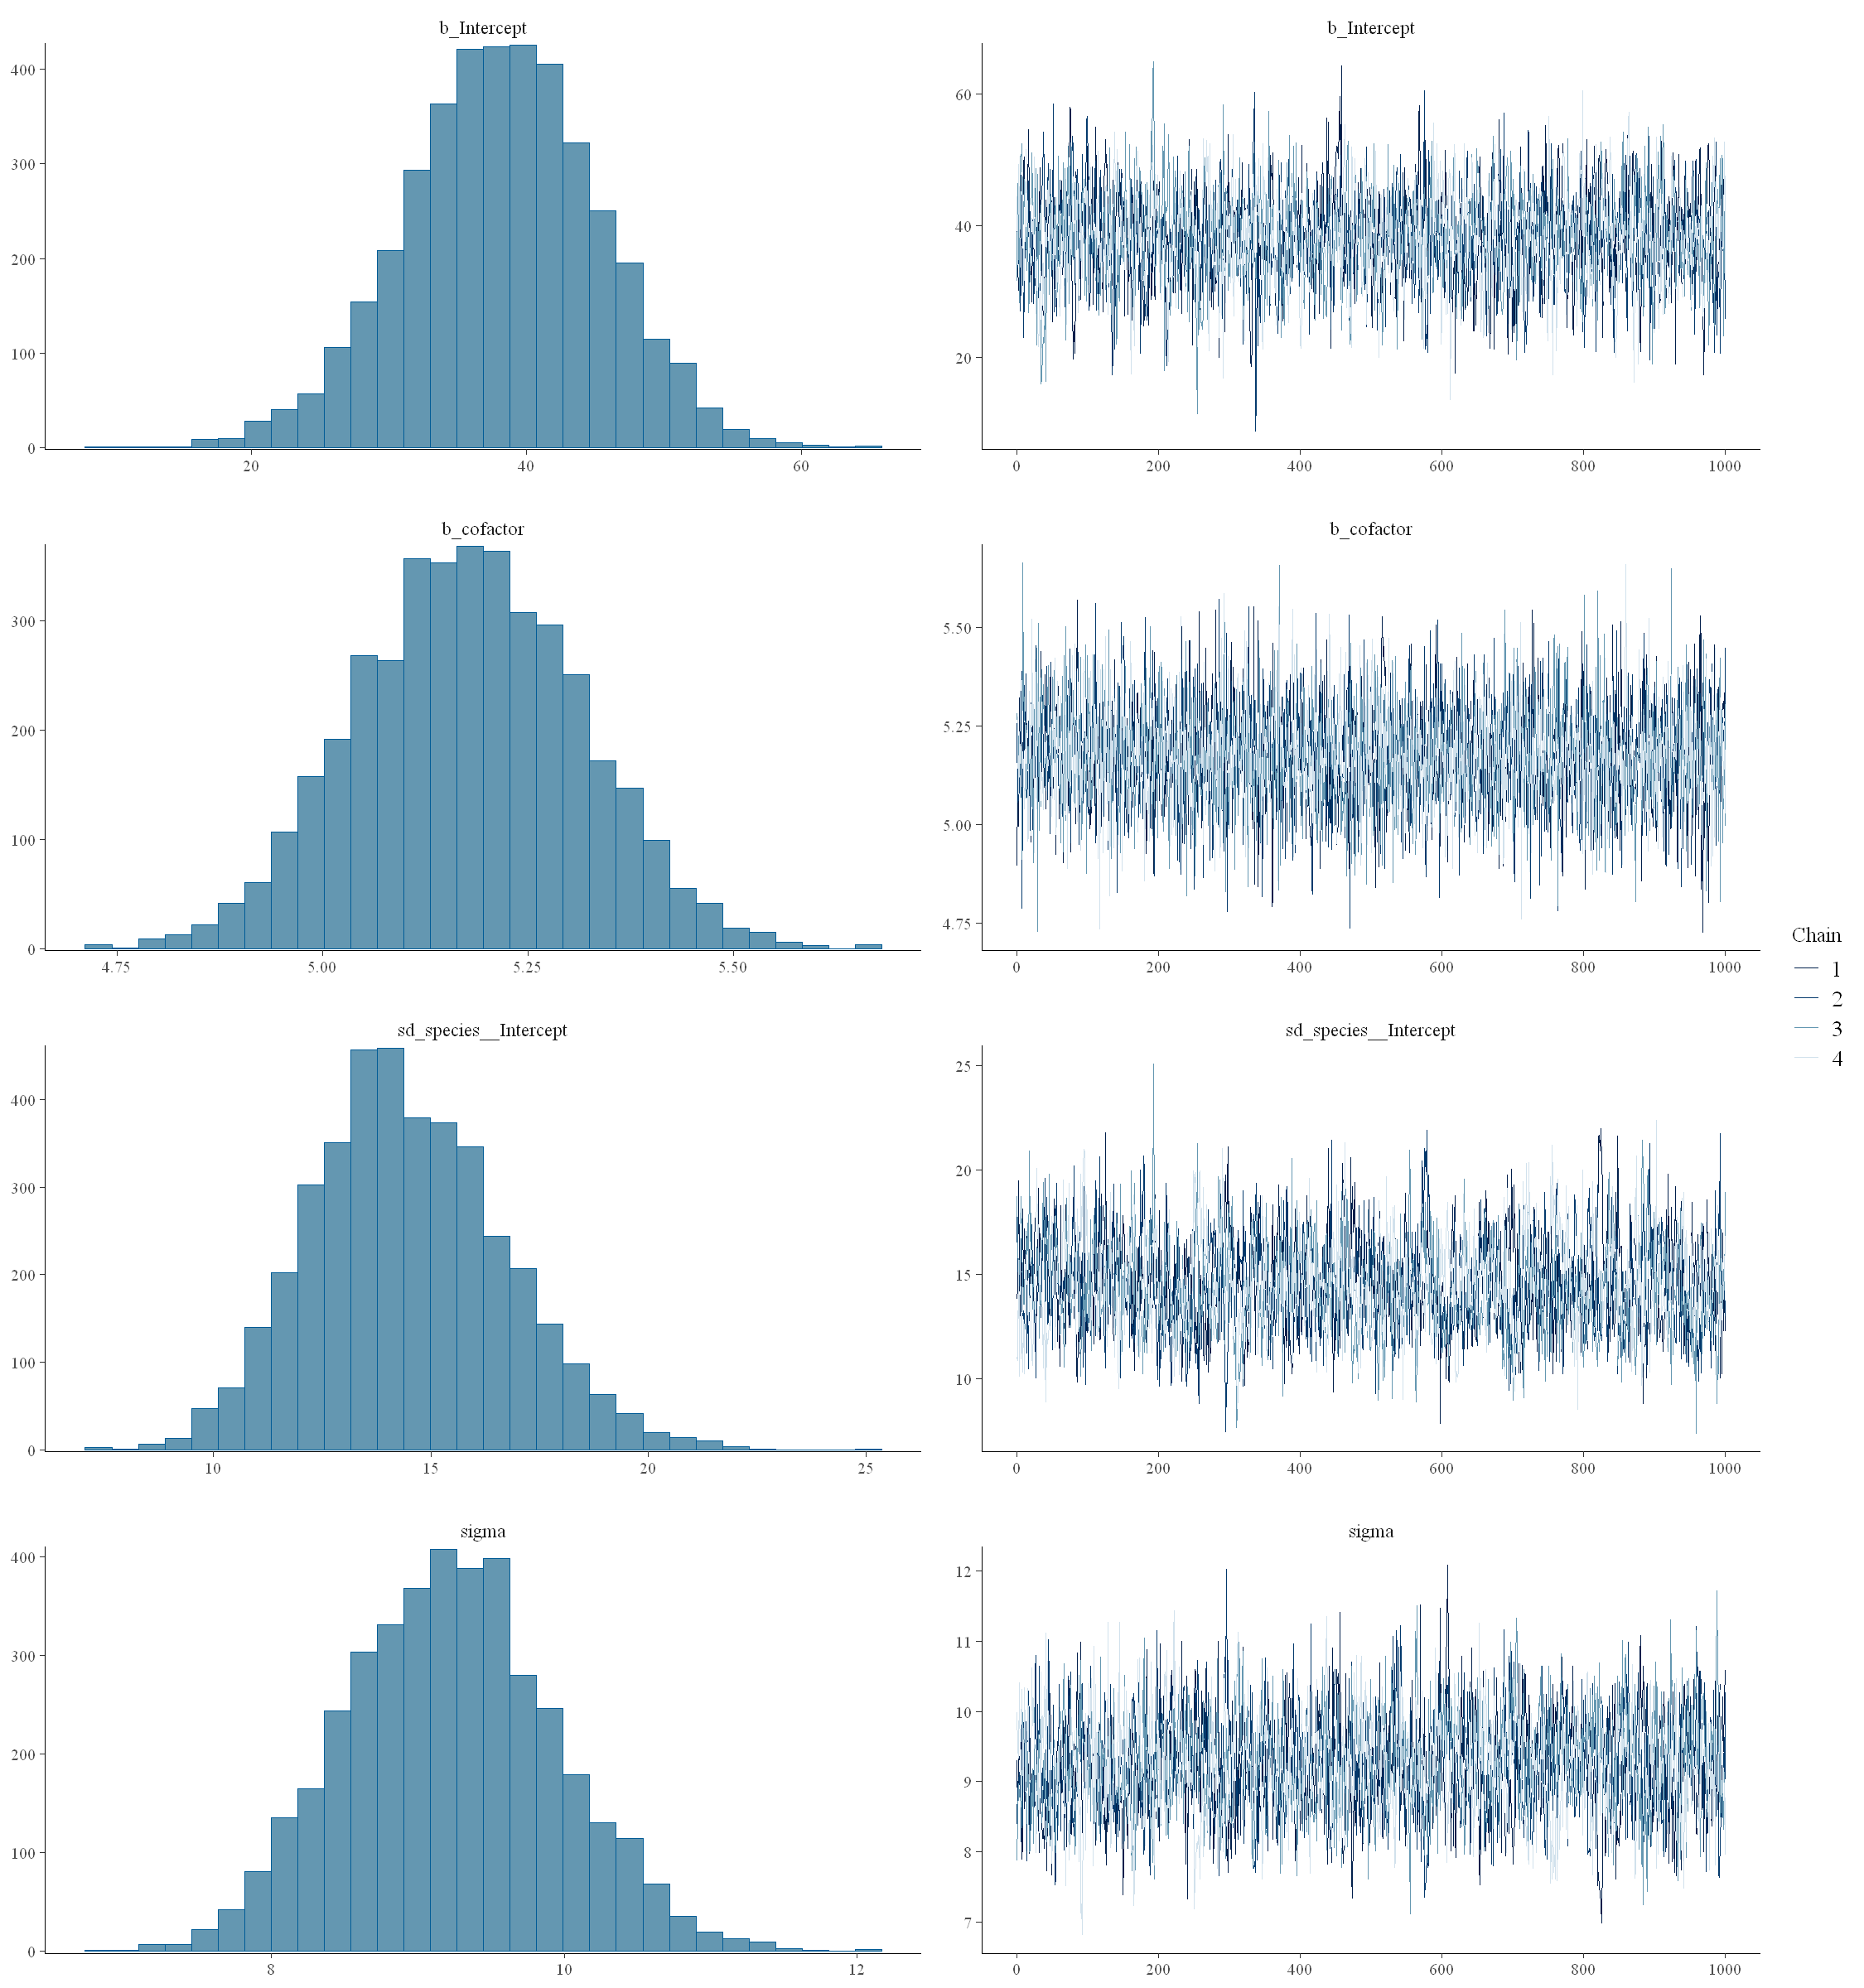

In [8]:
options(repr.plot.width = 15, repr.plot.height = 16, repr.plot.res = 150)
plot(model)

Ignoring unknown labels:
• fill : "NA"
• colour : "NA"
Ignoring unknown labels:
• fill : "NA"
• colour : "NA"


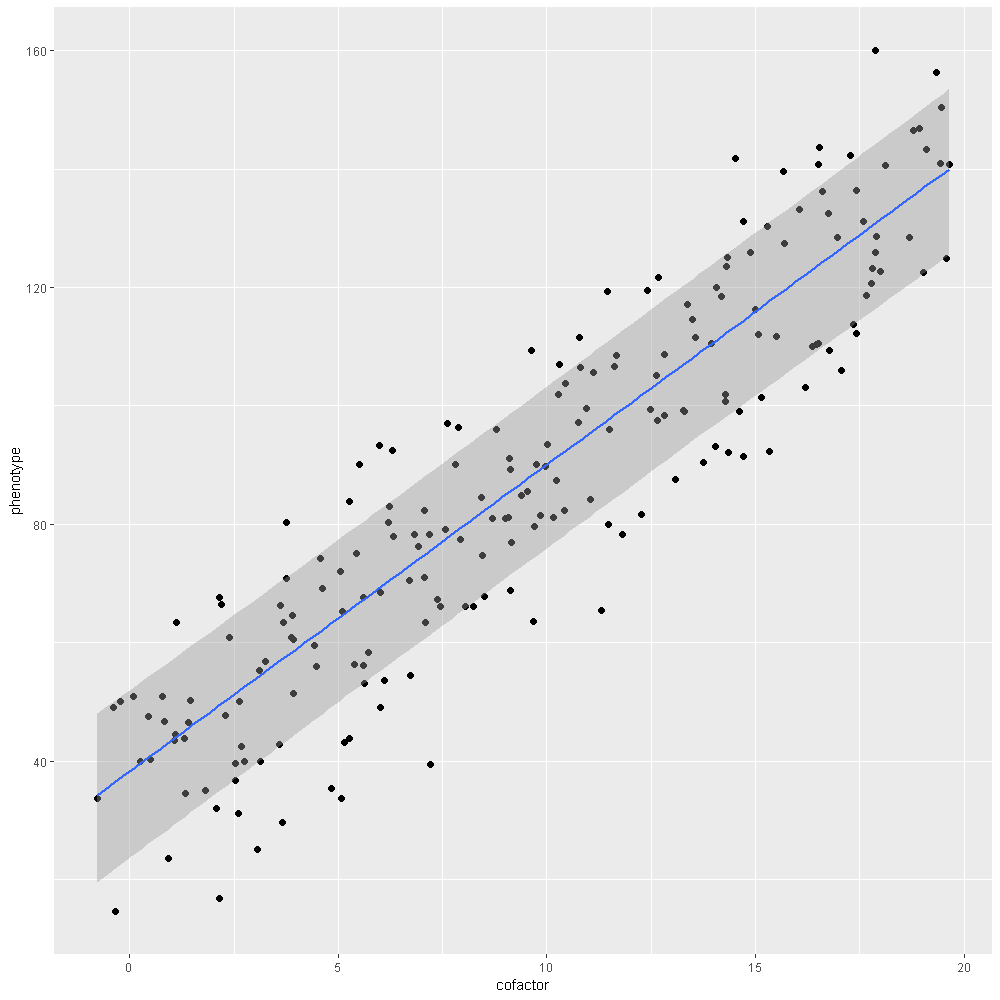

In [10]:
options(repr.plot.width = 10, repr.plot.height = 10, repr.plot.res = 100)
plot(brms::conditional_effects(model), points = TRUE)

In [11]:
data_1 <- data
rownames(data_1) <- data_1$species
head(data_1)

,phenotype,cofactor,species
,<dbl>,<dbl>,<chr>
sp_1,107.06595,10.309588,sp_1
sp_2,79.61086,9.690507,sp_2
sp_3,116.38186,15.007825,sp_3
sp_4,143.28705,19.087673,sp_4
sp_5,139.60993,15.658404,sp_5
sp_6,68.50657,6.005236,sp_6


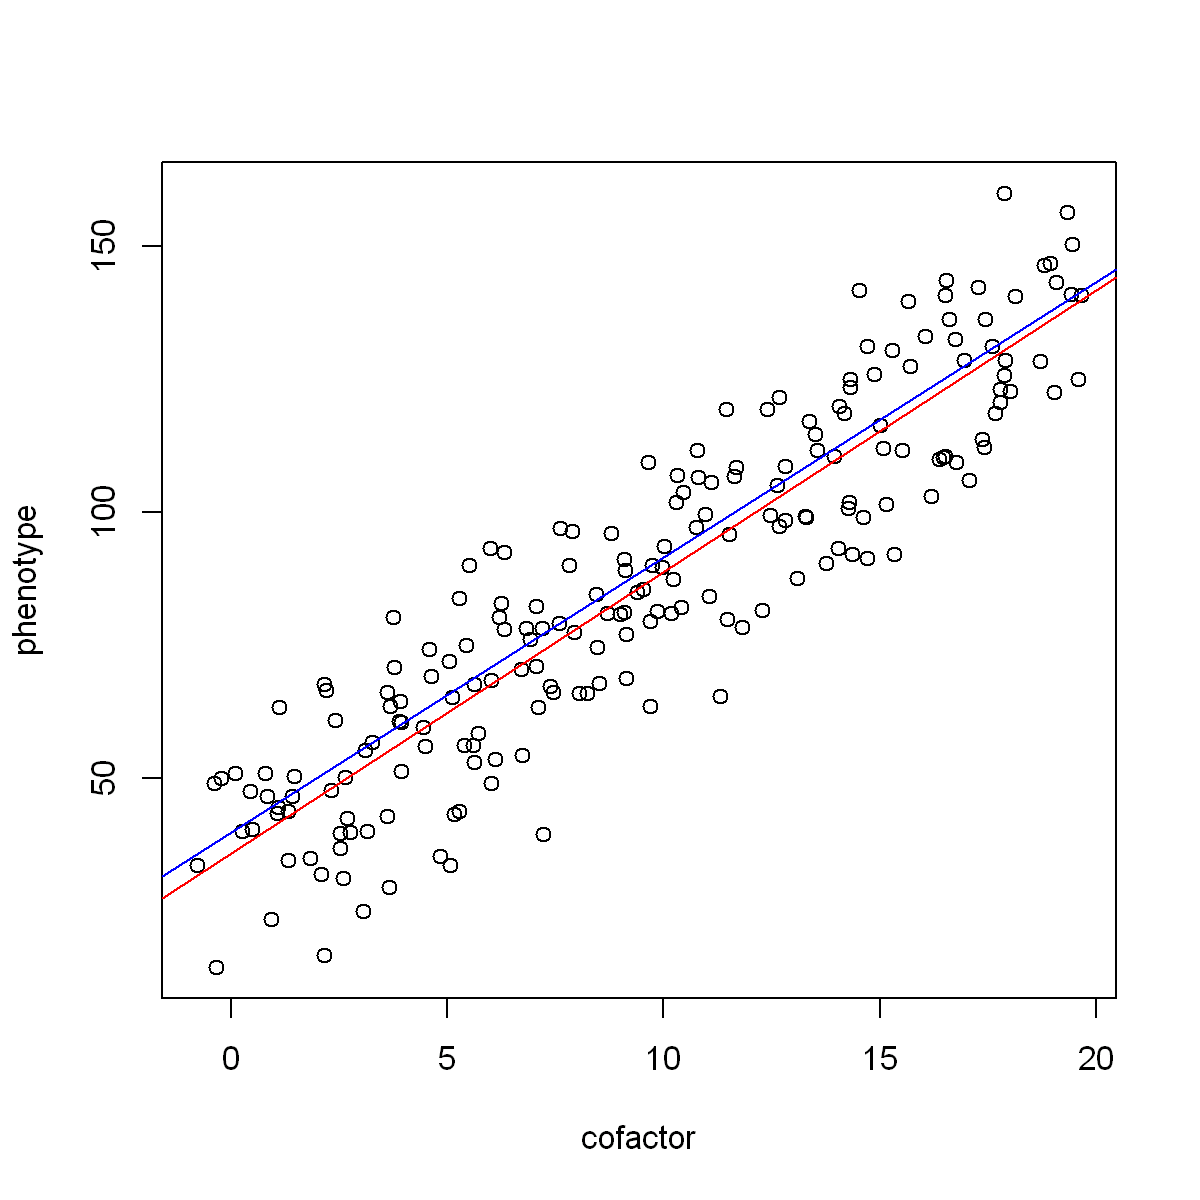

In [12]:
# see how this compares to PGLS

options(repr.plot.width = 6, repr.plot.height = 6, repr.plot.res = 200)

plot(phenotype ~ cofactor, data = data_1)
abline(lm(phenotype ~ cofactor, data = data_1), col = "red")
pgls <- phylolm::phylolm(phenotype ~ cofactor, data = data_1, model = "lambda", phy = phylo)
abline(pgls, col = "blue")

In [13]:
summary(pgls)


Call:
phylolm::phylolm(formula = phenotype ~ cofactor, data = data_1, 
    phy = phylo, model = "lambda")

   AIC logLik 
  1562   -777 

Raw residuals:
    Min      1Q  Median      3Q     Max 
-37.650 -12.944  -1.728   7.505  27.736 

Mean tip height: 1
Parameter estimate(s) using ML:
lambda : 0.7020354
sigma2: 282.2657 

Coefficients:
            Estimate  StdErr t.value   p.value    
(Intercept)  39.8007  6.8888  5.7776 2.904e-08 ***
cofactor      5.1763  0.1363 37.9770 < 2.2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

R-squared: 0.8793	Adjusted R-squared: 0.8787 

Note: p-values and R-squared are conditional on lambda=0.7020354.

In [5]:
# a lot of brms documentation and blogs focus on multilevel modelling - for nested group effects
# what we want is multiresponse models - multilevel models are no use in this context!!!

# ___`FRED 4` and `brms`___
----------------------

,binominal,F01286,F01287,F01289,F00679,F00727,F00709
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>
1,Larix_gmelinii,Larix,gmelinii,Pinaceae,0.3194115,32.211568,0.3542858
2,Larix_gmelinii,Larix,gmelinii,Pinaceae,0.4115552,25.480815,0.2942859
3,Larix_gmelinii,Larix,gmelinii,Pinaceae,0.5276214,12.980828,0.3828573
4,Larix_gmelinii,Larix,gmelinii,Pinaceae,0.8469749,6.250067,0.3342859
5,Larix_gmelinii,Larix,gmelinii,Pinaceae,0.3074501,34.615414,0.3828572
6,Larix_gmelinii,Larix,gmelinii,Pinaceae,0.4594009,26.442353,0.2600002


In [42]:
# model formulae
# do not use C++ style namespacing inside formulae e.g. brms::mi() or brms::gr()

form_y1 <- brms::brmsformula(F00679_mean | mi() + resp_se(F00679_sem, sigma = TRUE) ~ 1 + (1 | b | gr(binominal, cov = corrmat)))
form_y2 <- brms::brmsformula(F00727_mean | mi() + resp_se(F00727_sem, sigma = TRUE) ~ 1 + (1 | b | gr(binominal, cov = corrmat)))
form_y3 <- brms::brmsformula(F00709_mean | mi() + resp_se(F00709_sem, sigma = TRUE) ~ 1 + (1 | b | gr(binominal, cov = corrmat)))

In [19]:
getOption("brms.iter")

NULL

In [ ]:
# this crap takes days to run :/

fit_mean_brms <- brm(form_y1 + form_y2 + form_y3 + brms::set_rescor(TRUE),
              data    = traits_with_se,
              family  = stats::gaussian(), 
              data2   = list(corrmat_brms = corrmat_brms), # this list is in the format => name used in the formulae = actual object name
              control = list(adapt_delta = 0.95, max_treedepth = 12),
              iter = 5000, # default is 2000
              cores   = 14, 
              chains  = 6)

In [46]:
saveRDS(object = fit_mean_brms, file = "../../data/chapter2/rdata/brms_rd_srl_rtd.RData")

In [48]:
summary(fit_mean_brms)

 Family: MV(gaussian, gaussian, gaussian) 
  Links: mu = identity
         mu = identity
         mu = identity 
Formula: F00679_mean | mi() + resp_se(F00679_sem, sigma = TRUE) ~ 1 + (1 | b | gr(binominal, cov = corrmat_brms)) 
         F00727_mean | mi() + resp_se(F00727_sem, sigma = TRUE) ~ 1 + (1 | b | gr(binominal, cov = corrmat_brms)) 
         F00709_mean | mi() + resp_se(F00709_sem, sigma = TRUE) ~ 1 + (1 | b | gr(binominal, cov = corrmat_brms)) 
   Data: traits_with_se (Number of observations: 569) 
  Draws: 4 chains, each with iter = 2000; warmup = 1000; thin = 1;
         total post-warmup draws = 4000

Multilevel Hyperparameters:
~binominal (Number of levels: 569) 
                                               Estimate Est.Error l-95% CI
sd(F00679mean_Intercept)                           0.74      0.05     0.64
sd(F00727mean_Intercept)                           1.60      0.11     1.39
sd(F00709mean_Intercept)                           1.00      0.08     0.86
cor(F00679mean_

In [8]:
# "By including more diverse species in our phylogeny, we capture deeper splits that represent more meaningful divergences in the genotype and phenotype of extant lineages,
# precisely the effects we intend to model when analysing inter-species data."
# "One consequence of this, is that shallow topology (near the tips) is less informative than deep topology when attempting to infer patterns of phylogenetic niche conservatism, because differences between genera
# are usually more significant than differences between species within genera."

# "For higher taxonomic ranks (e.g. genus), it will usually be possible to derive a unique consensus tree by sampling a single species from each genus and simply pruning off the other tips from the tree.
# This approach may be problematic for lower taxonomic ranks however, because more closely related species are less likely to be monophyletic with respect to the taxonomic rank in question.
# Even in such cases, we can easily account for this phylogenetic uncertainty by randomly sampling topologies at the specified rank and fitting our models over this sample of trees."

In [16]:
# sample the phylogeny repeatedly, with one randomly chosen species per genera

NUNIQUE_GENERA <- length(unique(data$F01286)) # number of unique genera in our phylogeny
NSAMPLES = 100 # number of times to sample the original phylogeny
sampled_phylogenies <- list() # sampled sub phylogeneies with genera at tips
sampled_vcvs <- list()

for (i in 1:NSAMPLES) {
    sampled_species <- mapply(split.data.frame(data[, c("binominal", "F01286")], ~F01286), FUN = function(df) sample(df$binominal, 1)) # this is a vector of one randomly sampled species per each genera in the phylogeny
    subphylogeny <- ape::keep.tip(phy = phylogeny, tip = unname(sampled_species), trim.internal = TRUE) # trimmed phylogeny with one randomly sampled species per genus
    stopifnot(length(subphylogeny$tip.label)==NUNIQUE_GENERA)
                                     
    if(!ape::is.binary(subphylogeny)) subphylogeny <- ape::multi2di(subphylogeny) # make bifucracting if not already
    if(!ape::is.ultrametric(subphylogeny)) subphylogeny <- phytools::force.ultrametric(subphylogeny, method = "extend", message = FALSE) # make ultrametric if not already

    subphylogeny$tip.label <- gsub(subphylogeny$tip.label, pattern = "_[-a-z]+", replacement = '', fixed = FALSE) # replace the tip labels (binominal names) with genus names
    stopifnot(length(setdiff(subphylogeny$tip.label, unique(data$F01286))) == 0)
                              
    sampled_phylogenies[[i]] <- subphylogeny
    sampled_vcvs[[i]] <- ape::vcv.phylo(phy = subphylogeny, corr = TRUE) # computes the expected variances and covariances of a continuous phenotype assuming it evolves under a Brownian motion model
}

stopifnot(length(sampled_phylogenies) == length(sampled_vcvs))

In [ ]:
# create list of C matrices and dfs for use with brm_multiple() - DONT KNOW WTF THESE ARE????